In [13]:
def get_correlation(set1, set2):
    correlation = np.zeros((len(set1), len(set2)))
    emb1, emb2 = [], []
    for x in tqdm(range(len(set1))):
        f1 = embed(Image.fromarray(set1[x]))
        emb1.append(f1)
    for y in tqdm(range(len(set2))):
        f2 = embed(Image.fromarray(set2[y]))
        emb2.append(f2)
    for x in range(len(set1)):
        for y in range(len(set2)):
            score = cosine_sim(emb1[x], emb2[y])
            correlation[x,y] = score
    return correlation

In [14]:
c = get_correlation(set1, set2)

100%|██████████| 619/619 [00:41<00:00, 14.75it/s]


In [ ]:
%matplotlib qt
def super_plot(c, set1, set2):
    def onclick(event):
        if event.inaxes == ax:
            # round to nearest integer indices
            x = int(round(event.xdata))
            y = int(round(event.ydata))
            print(f"Clicked: x={x}, y={y}")

            # concatenate the chosen images horizontally
            if 0 <= x < len(set1) and 0 <= y < len(set2):
                combined = np.concatenate((set1[x], set2[y]), axis=1)

                # open a new figure to show concatenation
                plt.figure()
                plt.imshow(combined, cmap="gray")
                plt.title(f"Concatenated Image1[{x}] + Image2[{y}]")
                plt.axis("off")
                plt.show()

    fig, ax = plt.subplots()
    heatmap = ax.imshow(c, cmap="hot", interpolation="nearest")
    plt.colorbar(heatmap)
    y, x = np.where(c > 0.9)
    plt.scatter(x, y, facecolors='none', edgecolors='green', s=1, linewidths=0.1)

    cid = fig.canvas.mpl_connect("button_press_event", onclick)
    plt.show()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


In [155]:
%%time
correlations = np.zeros((dataset[0]['length'], dataset[1]['length']))

set1 = [dataset.timestep(idx=0, t=i).image for i in range(dataset[0]['length'])]
set2 = [dataset.timestep(idx=1, t=i).image for i in range(dataset[1]['length'])]

for i in tqdm(range(dataset[0]['length'])):
    for j in range(dataset[1]['length']):
        a, b = sm.similar_scene(set1[i], set2[j])
        correlations[i,j] = a

100%|██████████| 767/767 [1:14:31<00:00,  5.83s/it]

CPU times: user 1h 21min 1s, sys: 9min 16s, total: 1h 30min 18s
Wall time: 1h 17min 18s


In [141]:
%%time
img1 = dataset.timestep(idx=0, t=i).image
img2 = dataset.timestep(idx=1, t=j).image

CPU times: user 423 ms, sys: 507 ms, total: 931 ms
Wall time: 187 ms


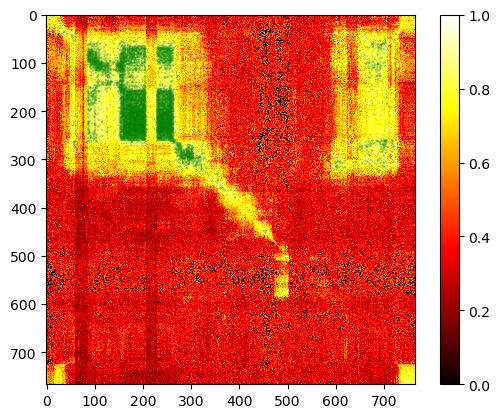

In [157]:
%matplotlib inline
super_plot(correlations, dataset[0], dataset[1])